[*********************100%***********************]  1 of 1 completed


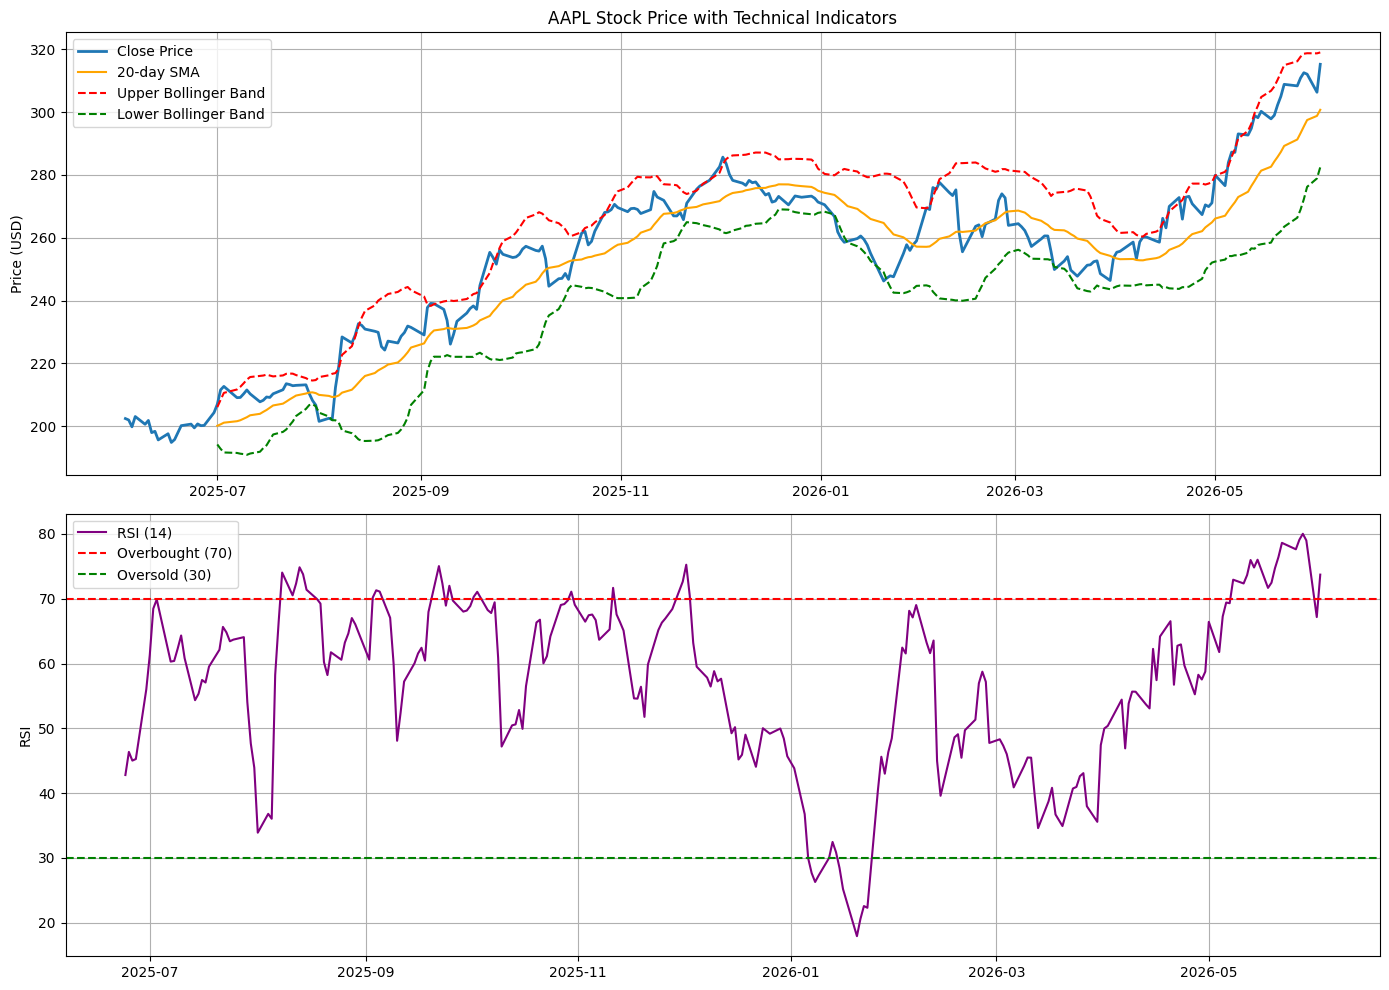

In [9]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = yf.download("AAPL", period="1y", interval="1d")

def sma(data, window):
    return data['Close'].rolling(window=window).mean()

data['SMA_20'] = sma(data, 20)

#boolinger bands

def bollinger_bands(data, window):
    mean = sma(data, window)
    std = data['Close'].rolling(window=window).std()
    upper_band = mean + (std * 2)
    lower_band = mean - (std * 2)
    return upper_band, lower_band

data['Upper_Band'], data['Lower_Band'] = bollinger_bands(data, 20)

#RSI

def rsi(data, window=14):
    delta = data['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    avg_gain = gain.ewm(alpha=1/window, adjust=False, min_periods=14).mean()
    avg_loss = loss.ewm(alpha=1/window, adjust=False, min_periods=14).mean()
    
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

data['RSI'] = rsi(data, 14)

plt.figure(figsize=(14, 10))

# Top Plot: Price + SMA + Bollinger Bands
plt.subplot(2, 1, 1)
plt.plot(data['Close'], label='Close Price', linewidth=2)
plt.plot(data['SMA_20'], label='20-day SMA', color='orange')
plt.plot(data['Upper_Band'], label='Upper Bollinger Band', linestyle='--', color='red')
plt.plot(data['Lower_Band'], label='Lower Bollinger Band', linestyle='--', color='green')
plt.title('AAPL Stock Price with Technical Indicators')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

# Bottom Plot: RSI
plt.subplot(2, 1, 2)
plt.plot(data['RSI'], label='RSI (14)', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.ylabel('RSI')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Options Theory Notes (Chapter 4 - Basic Strategies)

- **Covered Call Strategy**: A covered call involves owning 100 shares of a stock and selling (writing) a call option against those shares. The goal is to generate premium income from the sold call while still holding the underlying stock.

- **Best Time to Sell Covered Calls**: The ideal market condition is **sideways to mildly bullish**. In these environments, the stock is less likely to be called away (assigned), allowing the seller to keep both the stock and the full premium collected.

- **Advantages**:
  - Generates steady income through option premiums.
  - Provides some downside protection (the premium reduces effective cost basis).

- **Risks**:
  - Limited upside potential — if the stock rises sharply above the strike price, the shares may be called away.
  - Downside risk still exists (though partially offset by the premium). In case of a sudden crash (Black Swan event), the strategy cannot fully protect against large losses.